In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("AD_GEO_merged_DEG.csv")
print("Original shape:", df.shape)

Original shape: (119636, 7)


In [ ]:
# Remove NA rows
df = df.dropna()
print("After NA removal:", df.shape)


After NA removal: (88159, 7)


In [ ]:
# Target (continuous)
y = df["log2FoldChange"]

# Features (independent statistics)
X = df[["baseMean", "lfcSE", "stat"]]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (88159, 3)
y shape: (88159,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (70527, 3) (70527,)
Test: (17632, 3) (17632,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression R²: 0.5043139108872069
Linear Regression RMSE: 0.2647162577469761


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R²:", r2_score(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

RF R²: 0.9985756095368521
RF RMSE: 0.014190306556457885


In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
param_grid = {
    "n_estimators": [100],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}


In [ ]:
y = df["log2FoldChange"]     # continuous target
X = df[["baseMean", "lfcSE", "stat"]]  # NO leakage


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


In [ ]:
X_sub = X_train.sample(n=10000, random_state=42)
y_sub = y_train.loc[X_sub.index]


In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_sub, y_sub)


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
print("Best params:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.9936060371971691


In [ ]:
rf_best = RandomForestRegressor(
    **rf_grid.best_params_,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)
y_pred = rf_best.predict(X_test)

print("Final R2:", r2_score(y_test, y_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Final R2: 0.998560200404528
Final RMSE: 0.014266855833014826


In [ ]:
###########

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R2:", lr_r2)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression R2: 0.5043139108872069
Linear Regression RMSE: 0.2647162577469761


In [ ]:
from sklearn.svm import SVR

In [ ]:
svr = SVR(
    kernel="rbf",
    C=10,
    gamma="scale",
    epsilon=0.01
)

svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("SVR R2:", svr_r2)
print("SVR RMSE:", svr_rmse)

SVR R2: 0.9996646817621221
SVR RMSE: 0.00688502999658118


In [ ]:
rf_r2 = 0.99856
rf_rmse = 0.01426


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR (RBF)", "Random Forest"],
    "R2 Score": [lr_r2, svr_r2, rf_r2],
    "RMSE": [lr_rmse, svr_rmse, rf_rmse]
})

results


,Model,R2 Score,RMSE
0,Linear Regression,0.504314,0.264716
1,SVR (RBF),0.999665,0.006885
2,Random Forest,0.998560,0.014260


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


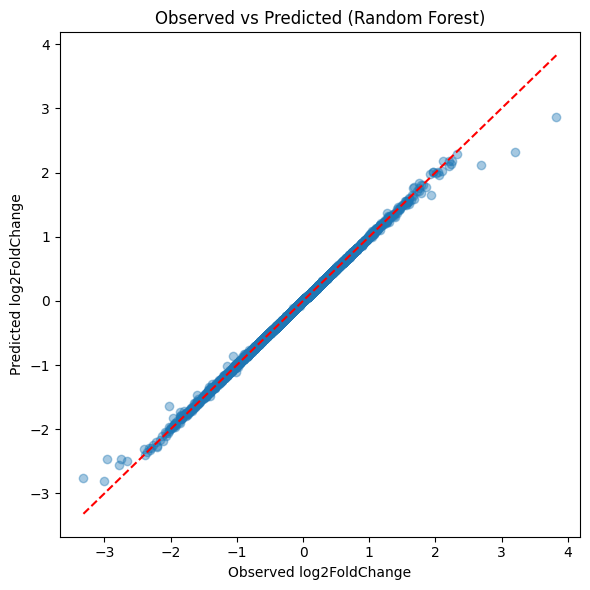

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Observed log2FoldChange")
plt.ylabel("Predicted log2FoldChange")
plt.title("Observed vs Predicted (Random Forest)")
plt.tight_layout()
plt.show()


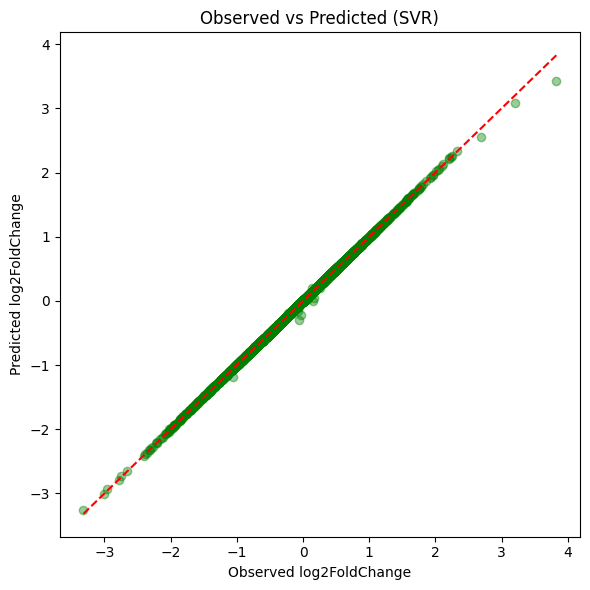

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.4, color="green")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Observed log2FoldChange")
plt.ylabel("Predicted log2FoldChange")
plt.title("Observed vs Predicted (SVR)")
plt.tight_layout()
plt.show()


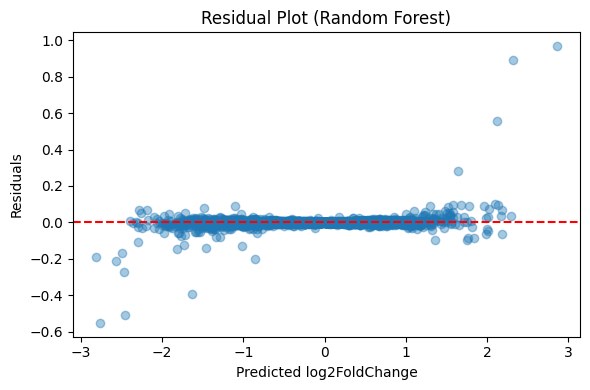

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted log2FoldChange")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")
plt.tight_layout()
plt.show()


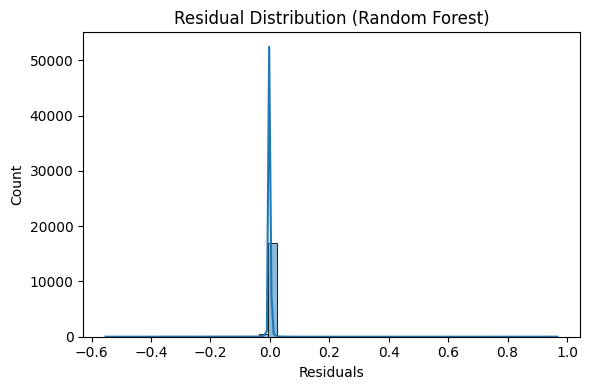

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals")
plt.title("Residual Distribution (Random Forest)")
plt.tight_layout()
plt.show()


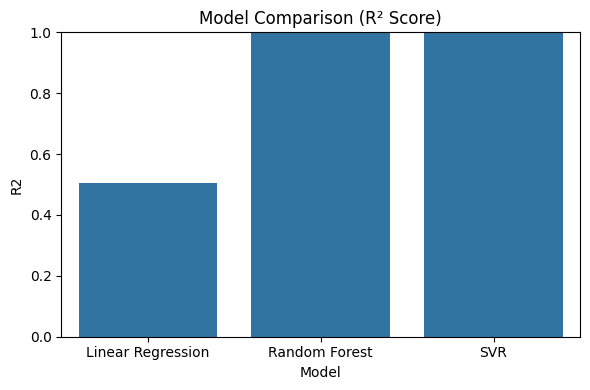

In [ ]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "SVR"],
    "R2": [lr_r2, rf_r2, svr_r2],
    "RMSE": [lr_rmse, rf_rmse, svr_rmse]
})

plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("Model Comparison (R² Score)")
plt.ylim(0,1)
plt.tight_layout()
plt.show()


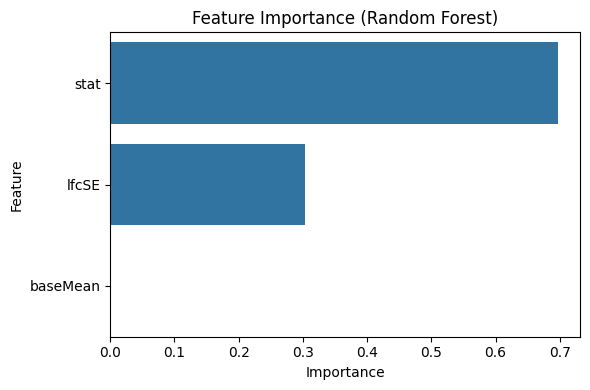

In [ ]:
importances = rf_best.feature_importances_
features = ["baseMean", "lfcSE", "stat"]

fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x="Importance", y="Feature", data=fi_df)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()


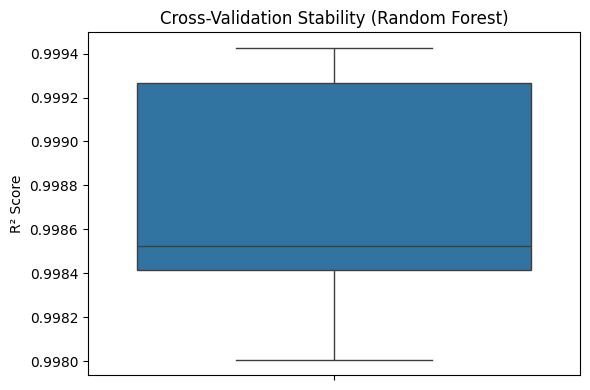

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_best,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

plt.figure(figsize=(6,4))
sns.boxplot(cv_scores)
plt.ylabel("R² Score")
plt.title("Cross-Validation Stability (Random Forest)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np


In [ ]:
# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Fit model
gbr.fit(X_train, y_train)

# Predict
y_pred_gbr = gbr.predict(X_test)

# Metrics
gbr_r2 = r2_score(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("Gradient Boosting R²:", gbr_r2)
print("Gradient Boosting RMSE:", gbr_rmse)

Gradient Boosting R²: 0.9764316570261927
Gradient Boosting RMSE: 0.05772205361434388


In [ ]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42
)

enet.fit(X_train_scaled, y_train)
y_pred_enet = enet.predict(X_test_scaled)

enet_r2 = r2_score(y_test, y_pred_enet)
enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred_enet))

print("ElasticNet R²:", enet_r2)
print("ElasticNet RMSE:", enet_rmse)


ElasticNet R²: 0.4770079969505243
ElasticNet RMSE: 0.27190974539058915


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

etr = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

etr.fit(X_train, y_train)
y_pred_etr = etr.predict(X_test)

etr_r2 = r2_score(y_test, y_pred_etr)
etr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_etr))

print("Extra Trees R2:", etr_r2)
print("Extra Trees RMSE:", etr_rmse)


Extra Trees R2: 0.9991075722547713
Extra Trees RMSE: 0.011232172925379246


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost R2:", xgb_r2)
print("XGBoost RMSE:", xgb_rmse)


XGBoost R2: 0.9746819665045549
XGBoost RMSE: 0.059826312360508005


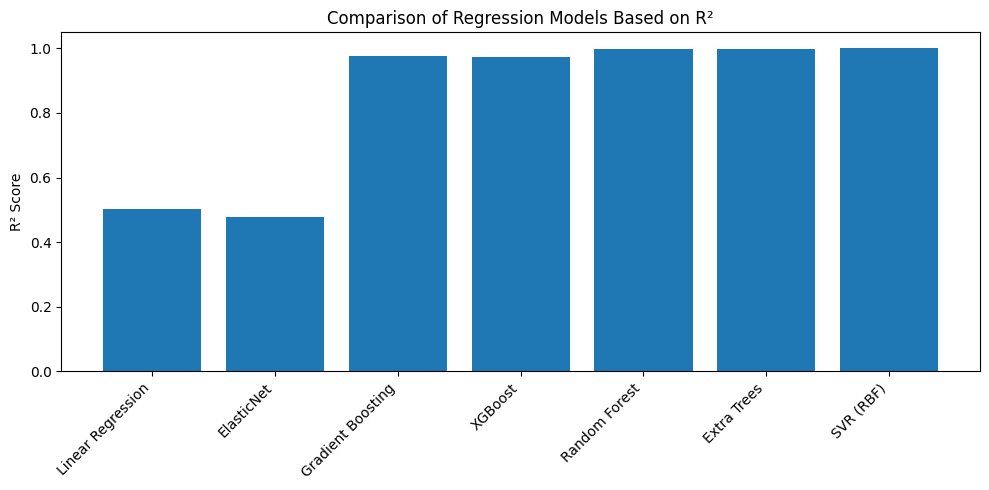

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Linear Regression",
    "ElasticNet",
    "Gradient Boosting",
    "XGBoost",
    "Random Forest",
    "Extra Trees",
    "SVR (RBF)"
]

r2_scores = [
    lr_r2,
    enet_r2,
    gbr_r2,
    xgb_r2,
    rf_r2,
    etr_r2,
    svr_r2
]

plt.figure(figsize=(10,5))
plt.bar(models, r2_scores)
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models Based on R²")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "ElasticNet",
        "Gradient Boosting",
        "XGBoost",
        "Extra Trees",
        "SVR (RBF)",
        "Random Forest"
    ],
    "R2 Score": [
        lr_r2,
        enet_r2,
        gbr_r2,
        xgb_r2,
        etr_r2,
        svr_r2,
        rf_r2
    ],
    "RMSE": [
        lr_rmse,
        enet_rmse,
        gbr_rmse,
        xgb_rmse,
        etr_rmse,
        svr_rmse,
        rf_rmse
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.504314,0.264716
1,ElasticNet,0.477008,0.271910
2,Gradient Boosting,0.976432,0.057722
3,XGBoost,0.974682,0.059826
4,Extra Trees,0.999108,0.011232
5,SVR (RBF),0.999665,0.006885
6,Random Forest,0.998560,0.014260


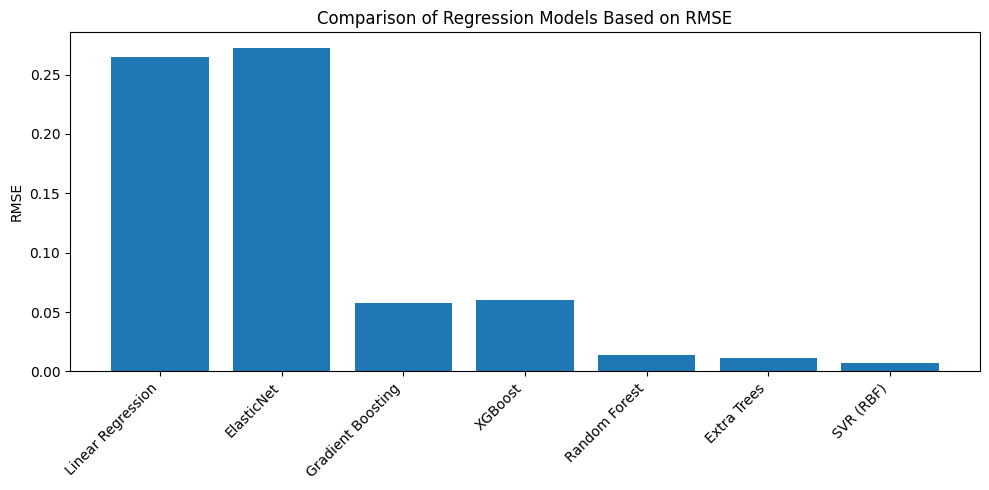

In [ ]:
rmse_scores = [
    lr_rmse,
    enet_rmse,
    gbr_rmse,
    xgb_rmse,
    rf_rmse,
    etr_rmse,
    svr_rmse
]

plt.figure(figsize=(10,5))
plt.bar(models, rmse_scores)
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Comparison of Regression Models Based on RMSE")
plt.tight_layout()
plt.show()


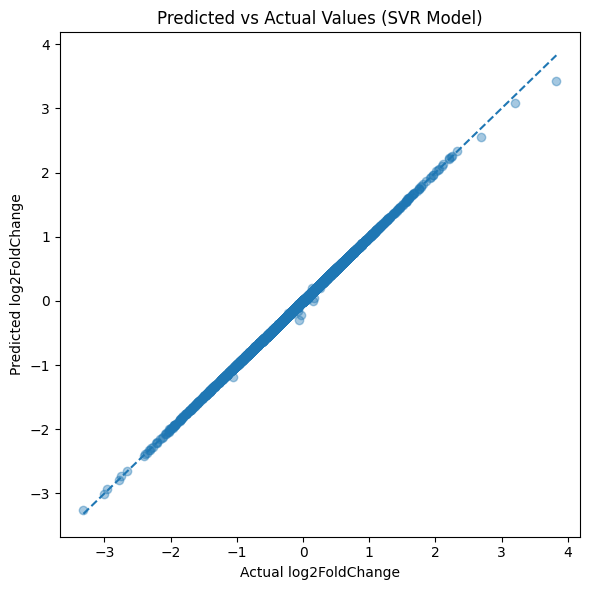

In [ ]:
import numpy as np

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual log2FoldChange")
plt.ylabel("Predicted log2FoldChange")
plt.title("Predicted vs Actual Values (SVR Model)")
plt.tight_layout()
plt.show()


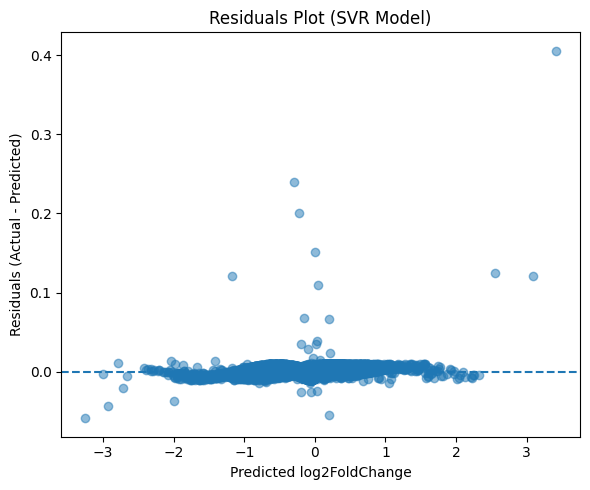

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals
residuals = y_test - y_pred_svr

plt.figure(figsize=(6,5))
plt.scatter(y_pred_svr, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log2FoldChange")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot (SVR Model)")
plt.tight_layout()
plt.show()


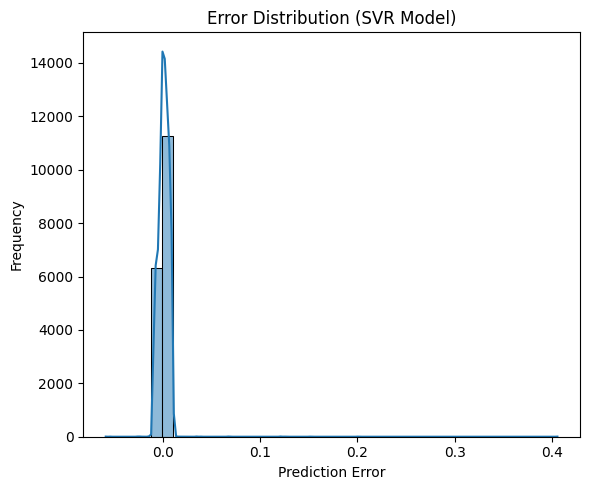

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (SVR Model)")
plt.tight_layout()
plt.show()


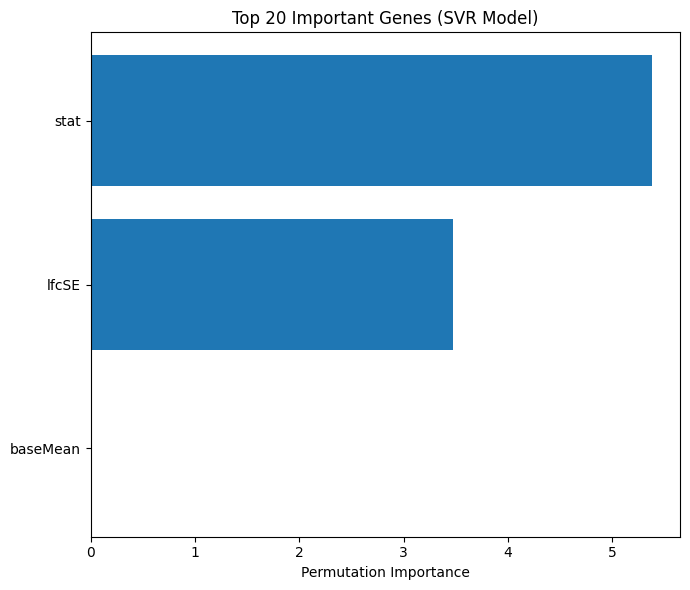

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Permutation importance
perm = permutation_importance(
    svr,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create DataFrame
feature_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

# Top 20 genes
top_features = feature_importance.head(20)

plt.figure(figsize=(7,6))
plt.barh(top_features["Gene"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.title("Top 20 Important Genes (SVR Model)")
plt.tight_layout()
plt.show()


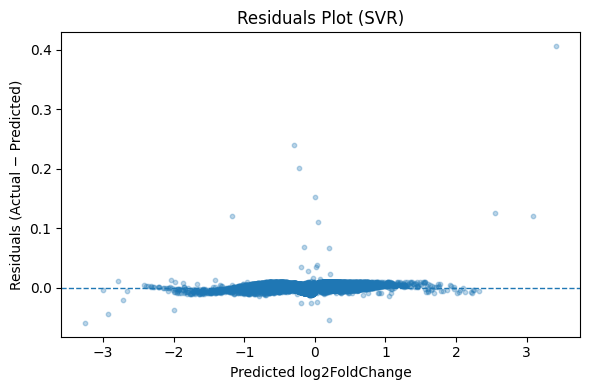

In [ ]:
residuals = y_test - y_pred_svr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_svr, residuals, alpha=0.3, s=10)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted log2FoldChange")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residuals Plot (SVR)")
plt.tight_layout()
plt.show()


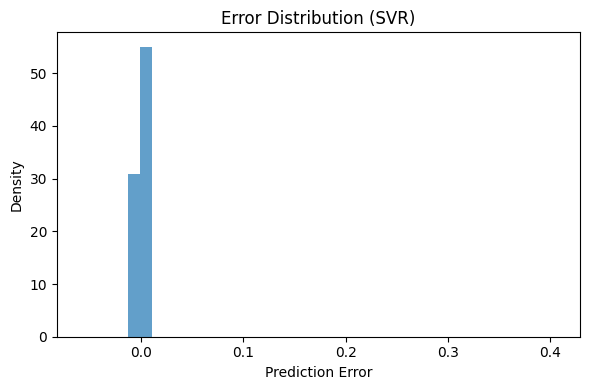

In [ ]:
errors = y_test - y_pred_svr

plt.figure(figsize=(6,4))
plt.hist(errors, bins=40, density=True, alpha=0.7)
plt.xlabel("Prediction Error")
plt.ylabel("Density")
plt.title("Error Distribution (SVR)")
plt.tight_layout()
plt.show()


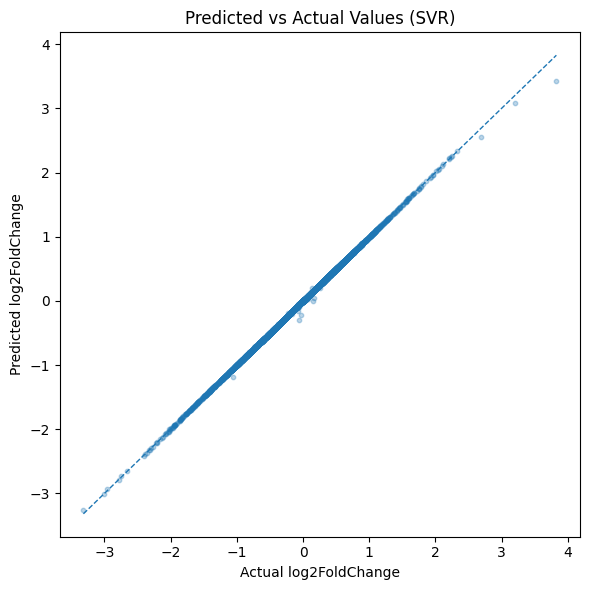

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', linewidth=1)
plt.xlabel("Actual log2FoldChange")
plt.ylabel("Predicted log2FoldChange")
plt.title("Predicted vs Actual Values (SVR)")
plt.tight_layout()
plt.show()


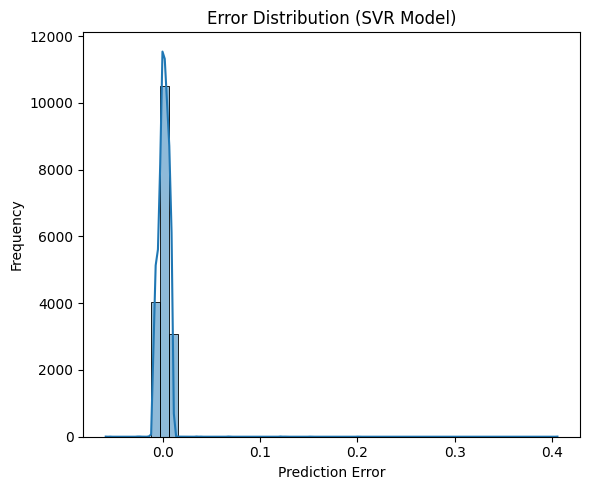

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

errors = y_test - y_pred_svr

plt.figure(figsize=(6,5))
sns.histplot(errors, bins=50, kde=True)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (SVR Model)")
plt.tight_layout()
plt.show()


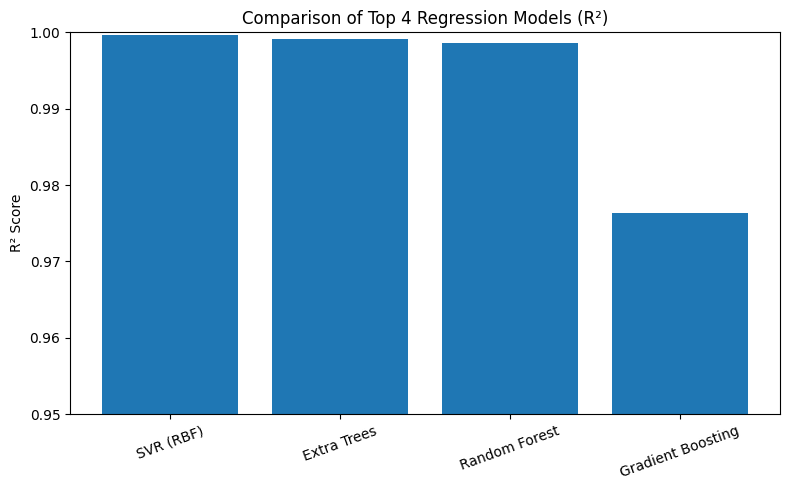

In [ ]:
import matplotlib.pyplot as plt

models = ["SVR (RBF)", "Extra Trees", "Random Forest", "Gradient Boosting"]
r2_scores = [0.9997, 0.9991, 0.9986, 0.9764]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.ylabel("R² Score")
plt.title("Comparison of Top 4 Regression Models (R²)")
plt.ylim(0.95, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


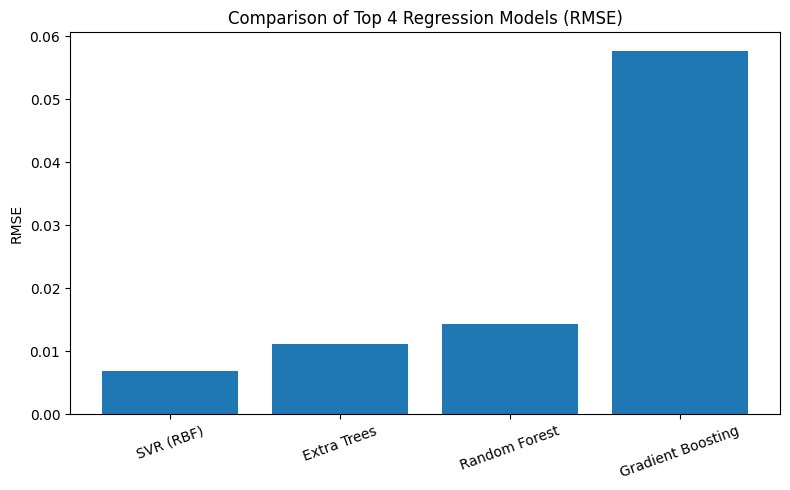

In [ ]:
rmse_scores = [0.0069, 0.0112, 0.0143, 0.0577]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores)
plt.ylabel("RMSE")
plt.title("Comparison of Top 4 Regression Models (RMSE)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [ ]:
#top 50 genes

In [ ]:
import pandas as pd

df = pd.read_csv("AD_GEO_merged_DEG.csv")


In [ ]:
df = df.dropna(subset=["baseMean", "log2FoldChange", "stat", "pvalue"])

In [ ]:
import numpy as np

df["ranking_score"] = (
    np.abs(df["log2FoldChange"]) * np.abs(df["stat"])
)

In [ ]:
top50_genes = (
    df.sort_values("ranking_score", ascending=False)
      .head(50)
)

In [ ]:
top50_genes_final = top50_genes[
    ["Gene", "baseMean", "log2FoldChange", "lfcSE", "stat", "pvalue", "padj"]
]

In [ ]:
top50_genes_final.to_csv("Top50_ML_Prioritized_Genes.csv", index=False)

In [ ]:
top50_genes_final.head(10)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
25934,SLC12A1,3.090602,3.827276,1.087659,3.518821,4.334690e-04,0.506586
95394,SNTB1-AS2,5.024132,-2.189048,0.430675,-5.082830,3.720000e-07,0.016109
10369,SLC12A1,3.090602,3.249387,1.078862,3.011865,2.596483e-03,0.998648
12586,CELF5,1.766201,-2.968106,0.944068,-3.143954,1.666815e-03,0.998648
16515,SERTAD4,0.958638,-3.317546,1.181729,-2.807365,4.994854e-03,0.826083
99893,NaN,2.254486,-4.670838,2.448379,-1.907727,5.642652e-02,0.999962
16268,DDR2,1.141210,-2.743364,0.867370,-3.162854,1.562308e-03,0.553003
18602,ATP13A4,0.951152,-2.528489,0.752101,-3.361900,7.740820e-04,0.506586
4344,MATR3_2,2.175441,-3.921406,1.820534,-2.153987,3.124122e-02,0.998648
43275,LOC650293,1.960253,-2.512485,0.756687,-3.320375,8.989660e-04,0.685885


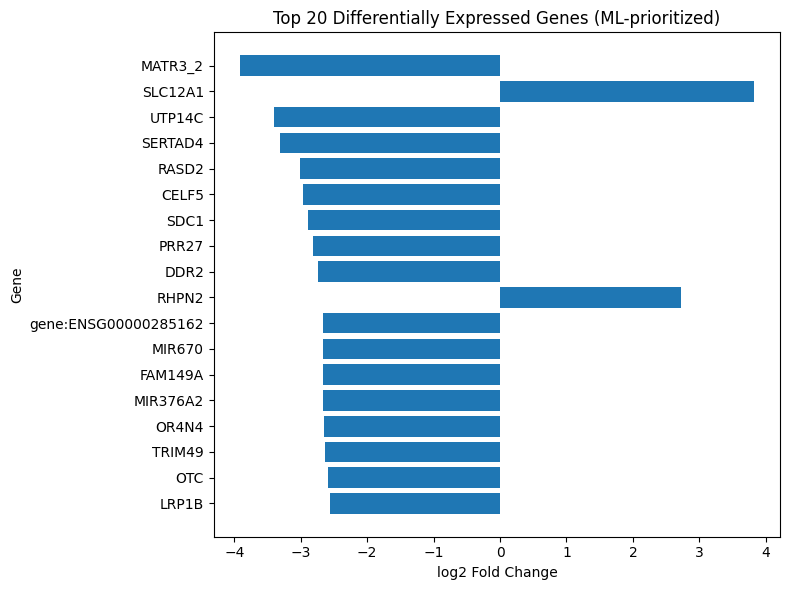

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

top20 = top50_genes_final.copy()
top20["abs_log2FC"] = np.abs(top20["log2FoldChange"])
top20 = top20.sort_values("abs_log2FC", ascending=False).head(20)
top20 = top20.dropna(subset=["Gene"]) # Remove rows with NaN in 'Gene' column

plt.figure(figsize=(8,6))
plt.barh(top20["Gene"], top20["log2FoldChange"])
plt.xlabel("log2 Fold Change")
plt.ylabel("Gene")
plt.title("Top 20 Differentially Expressed Genes (ML-prioritized)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

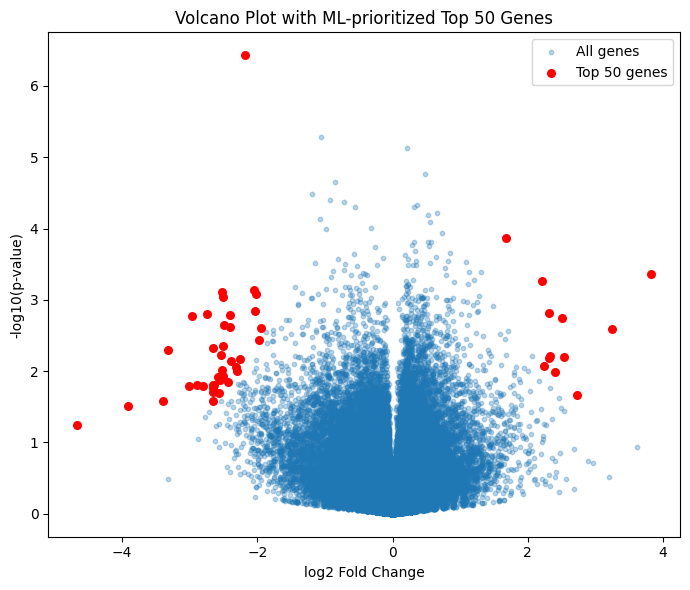

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["log2FoldChange"],
    -np.log10(df["pvalue"]),
    alpha=0.3,
    s=10,
    label="All genes"
)

plt.scatter(
    top50_genes_final["log2FoldChange"],
    -np.log10(top50_genes_final["pvalue"]),
    color="red",
    s=30,
    label="Top 50 genes"
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot with ML-prioritized Top 50 Genes")
plt.legend()
plt.tight_layout()
plt.show()


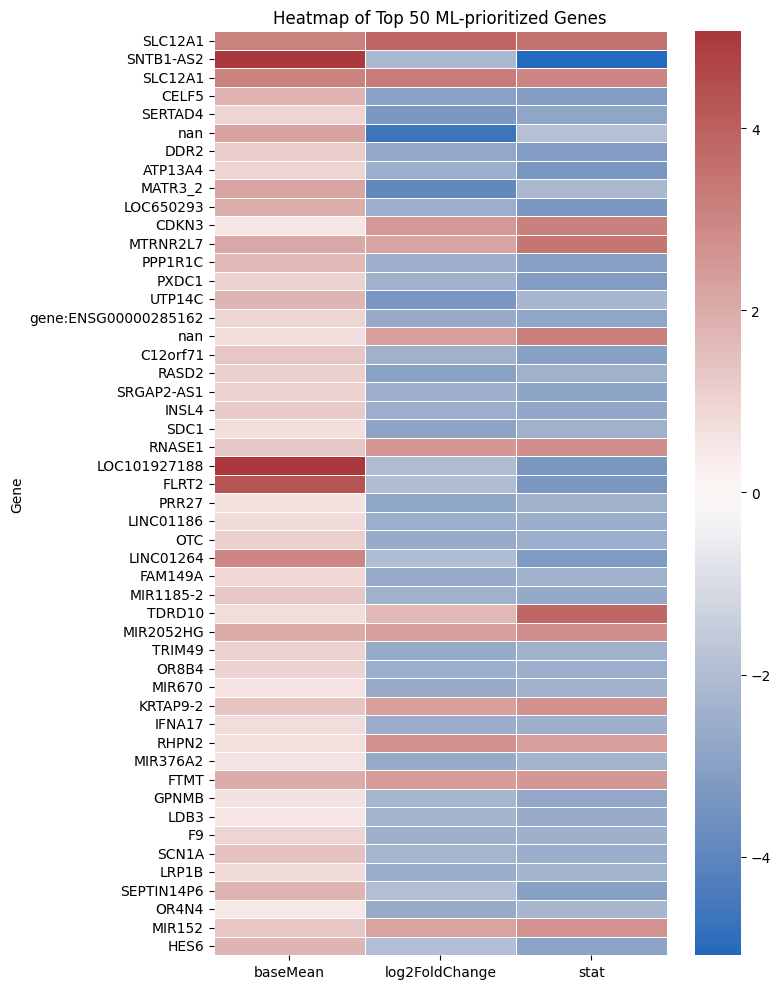

In [ ]:
import seaborn as sns

heatmap_data = top50_genes_final.set_index("Gene")[
    ["baseMean", "log2FoldChange", "stat"]
]

plt.figure(figsize=(8,10))
sns.heatmap(
    heatmap_data,
    cmap="vlag",
    center=0,
    linewidths=0.5
)
plt.title("Heatmap of Top 50 ML-prioritized Genes")
plt.tight_layout()
plt.show()


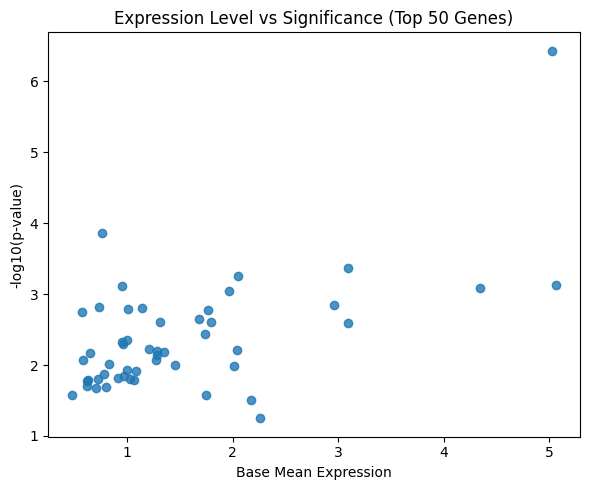

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(
    top50_genes_final["baseMean"],
    -np.log10(top50_genes_final["pvalue"]),
    alpha=0.8
)
plt.xlabel("Base Mean Expression")
plt.ylabel("-log10(p-value)")
plt.title("Expression Level vs Significance (Top 50 Genes)")
plt.tight_layout()
plt.show()


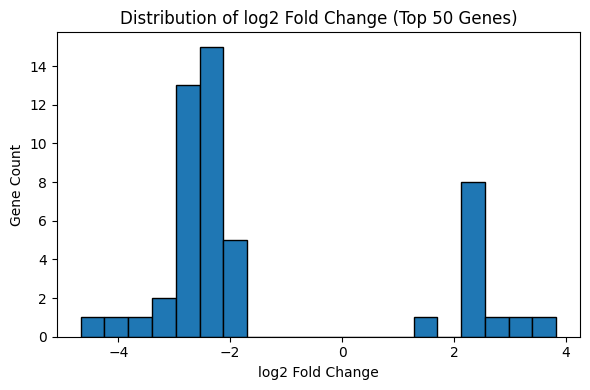

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(
    top50_genes_final["log2FoldChange"],
    bins=20,
    edgecolor="black"
)
plt.xlabel("log2 Fold Change")
plt.ylabel("Gene Count")
plt.title("Distribution of log2 Fold Change (Top 50 Genes)")
plt.tight_layout()
plt.show()
